# Benchmark Run + Plot + Summary Notebook

This notebook provides an end-to-end benchmark workflow:
1. Build a benchmark name/path map from `examples/*.transact`
2. Run each benchmark using `cargo run -- {benchmark_path} {output_dir}`
3. Load generated JSON output from the selected output directory
4. Plot:
   - Cactus plot (sorted solved times, log-scale Y)
   - Strip plot (per-benchmark time distributions, single-point benchmarks supported)
5. Print a summary table similar to `benchmark_analysis.ipynb`

In [1]:
import json
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- User-configurable paths --------
PROJECT_ROOT = Path('.').resolve()
EXAMPLES_DIRS = [PROJECT_ROOT / 'examples', PROJECT_ROOT / 'examples' / 'benchbase-hard']  # Add more example directories as needed
OUTPUT_ROOT = PROJECT_ROOT / 'tmp_plot'   # Change this to any other output root

# Build benchmark map from all transact files in examples/
BENCHMARK_MAP = {
    p.stem: str(p)
    for p in sorted([file for directory in EXAMPLES_DIRS for file in directory.glob('*.transact')])
}

# Special benchmark entry: include TPCC non-split dataset in later analysis loading.
# This path is JSON-only and does not need to be runnable by cargo.
BENCHMARK_MAP['TPC-C no split'] = str(PROJECT_ROOT / 'data_out_backup_out' / 'tpcc_out' / '61920' / 'data.json')

if not BENCHMARK_MAP:
    raise FileNotFoundError(f'No benchmark files found in {EXAMPLES_DIRS}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Examples dir:  {EXAMPLES_DIRS}')
print(f'Output root:   {OUTPUT_ROOT}')
print('\nBenchmark map (name -> path):')
for name, path in BENCHMARK_MAP.items():
    print(f'  {name:20s} -> {path}')

Project root: /scratch/yanjunc6/FMitF_rs
Examples dir:  [PosixPath('/scratch/yanjunc6/FMitF_rs/examples'), PosixPath('/scratch/yanjunc6/FMitF_rs/examples/benchbase-hard')]
Output root:   /scratch/yanjunc6/FMitF_rs/tmp_plot

Benchmark map (name -> path):
  auctionmark          -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/auctionmark.transact
  epinions             -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/epinions.transact
  resourcestresser     -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/resourcestresser.transact
  sibench              -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/sibench.transact
  smallbank            -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/smallbank.transact
  tatp                 -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/tatp.transact
  tpcds                -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/tpcds.transact
  tpch                 -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/

In [2]:
# Set to True to execute benchmarks; set to False to reuse already generated outputs
RUN_BENCHMARKS = True

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
run_results = []

if RUN_BENCHMARKS:
    for bench_name, bench_path in BENCHMARK_MAP.items():
        # Skip JSON-only benchmarks that are added for analysis comparison.
        if bench_name == 'TPC-C no split' or str(bench_path).endswith('.json'):
            print(f"Skipping cargo run for JSON-only benchmark: {bench_name}")
            continue

        bench_output_dir = OUTPUT_ROOT / bench_name
        bench_output_dir.mkdir(parents=True, exist_ok=True)

        cmd = ['cargo', 'run', '--', bench_path, str(bench_output_dir), "--clear-cache"]
        print('\nRunning:', ' '.join(cmd))

        start = time.time()
        completed = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
        elapsed = time.time() - start

        run_results.append({
            'benchmark': bench_name,
            'return_code': completed.returncode,
            'elapsed_seconds': elapsed,
            'stdout_tail': '\n'.join(completed.stdout.splitlines()[-8:]),
            'stderr_tail': '\n'.join(completed.stderr.splitlines()[-8:]),
        })

        status = 'OK' if completed.returncode == 0 else 'FAIL'
        print(f'[{status}] {bench_name} finished in {elapsed:.2f}s')

    run_df = pd.DataFrame(run_results)
    print('\nRun summary:')
    display(run_df[['benchmark', 'return_code', 'elapsed_seconds']])
else:
    print('RUN_BENCHMARKS=False, skipping execution. Using existing outputs in OUTPUT_ROOT.')


Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/auctionmark.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/auctionmark --clear-cache
[OK] auctionmark finished in 12.82s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/epinions.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/epinions --clear-cache
[OK] epinions finished in 2.27s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/resourcestresser.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/resourcestresser --clear-cache
[OK] resourcestresser finished in 4.58s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/sibench.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/sibench --clear-cache
[OK] sibench finished in 0.86s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-hard/smallbank.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/smallbank --clear-cache
[OK] smallbank finished in 4.14s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/e

,benchmark,return_code,elapsed_seconds
0,auctionmark,0,12.821556
1,epinions,0,2.265919
2,resourcestresser,0,4.583308
3,sibench,0,0.862283
4,smallbank,0,4.143540
5,tatp,0,1.784985
6,tpcds,0,0.769835
7,tpch,0,0.996289
8,twitter,0,0.897155
9,voter,0,0.863718


In [3]:
def find_data_json(benchmark_output_dir: Path):
    """Find data.json directly or recursively under a benchmark output folder."""
    direct = benchmark_output_dir / 'data.json'
    if direct.exists():
        return direct

    matches = sorted(benchmark_output_dir.glob('**/data.json'))
    return matches[0] if matches else None

datasets = {}
missing = []

# Special JSON-only benchmark path requested by user
special_json_paths = {
    'TPC-C no split': PROJECT_ROOT / 'data_out_backup_out' / 'tpcc_out' / '61920' / 'data.json',
}

for bench_name in BENCHMARK_MAP:
    effective_name = bench_name

    if bench_name in special_json_paths:
        json_path = special_json_paths[bench_name]
    elif bench_name == 'TPC-C no split' and str(BENCHMARK_MAP[bench_name]).endswith('.json'):
        json_path = Path(BENCHMARK_MAP[bench_name])
    else:
        bench_output_dir = OUTPUT_ROOT / bench_name
        json_path = find_data_json(bench_output_dir)

    if json_path is None or not Path(json_path).exists():
        missing.append((effective_name, str(json_path) if json_path is not None else str(OUTPUT_ROOT / bench_name)))
        continue

    with open(json_path, 'r') as f:
        datasets[effective_name] = json.load(f)

print('Loaded JSON datasets:')
for name in sorted(datasets):
    print(f'  {name}')

if missing:
    print('\nMissing data.json for:')
    for name, path_or_dir in missing:
        print(f'  {name:20s} (searched in {path_or_dir})')

if not datasets:
    raise RuntimeError('No datasets loaded. Run benchmarks first or check OUTPUT_ROOT.')

Loaded JSON datasets:
  TPC-C no split
  auctionmark
  epinions
  resourcestresser
  rubis
  sibench
  smallbank
  social
  tatp
  tpcc
  twitter
  voter
  wikipedia
  ycsb

Missing data.json for:
  tpcds                (searched in /scratch/yanjunc6/FMitF_rs/tmp_plot/tpcds)
  tpch                 (searched in /scratch/yanjunc6/FMitF_rs/tmp_plot/tpch)


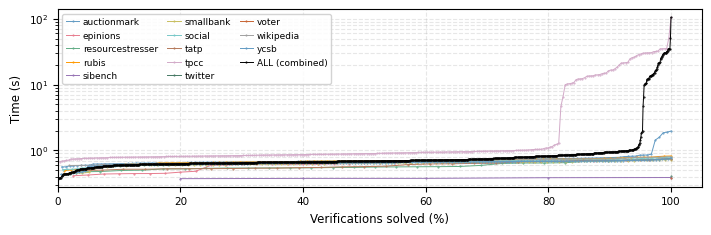

In [4]:
def extract_durations_seconds(data):
    verifications = data.get('c_edge_verifications', [])
    return [float(v['duration_ms']) / 1000.0 for v in verifications if 'duration_ms' in v]

durations_by_benchmark = {
    name: extract_durations_seconds(data)
    for name, data in datasets.items()
}
durations_by_benchmark['TPC-C no split'] = []

SHOW_COMBINED_CACTUS = True
CACTUS_MARKER = 'o'
CACTUS_MARKER_SIZE = 0.5
CACTUS_LINEWIDTH = 0.7

# ── Color palette (rooted in myblue / myred / mygreen / myorange) ──────
PALETTE = [
    '#619AC3',  # myblue    (97, 154, 195)
    '#E77C8E',  # myred     (231, 124, 142)
    '#61AC85',  # mygreen   (97, 172, 133)
    '#FF9900',  # myorange  (255, 153, 0)
    '#9673B4',  # purple
    '#C8BE5F',  # olive
    '#78C8C8',  # teal
    '#B4785A',  # brown
    '#D2AAC8',  # lavender
    '#467864',  # dark teal
    '#C86432',  # rust
    '#A0A0A0',  # gray
]

# ── Figure: A4 text-width, compact height ──────────────────────────────
fig_w = 7.0                # ≈ A4 text width (inches)
fig_h = fig_w * 0.32       # ~1/3 of width → fits 1/4–2/5 requirement
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

LABEL_FS  = 8.5
TICK_FS   = 7.5
LEGEND_FS = 6.5

# ── Per-benchmark lines (normalized x-axis → percentage) ──────────────
active = sorted(n for n in durations_by_benchmark
                if len(durations_by_benchmark[n]) > 0)

for idx, name in enumerate(active):
    times = np.array(sorted(durations_by_benchmark[name]), dtype=float)
    pct   = np.arange(1, len(times) + 1) / len(times) * 100.0   # ← key change
    ax.plot(pct, times,
            linewidth=CACTUS_LINEWIDTH,
            marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
            color=PALETTE[idx % len(PALETTE)],
            label=name)

# ── Combined cactus line ───────────────────────────────────────────────
if SHOW_COMBINED_CACTUS:
    combined = sorted(t for ts in durations_by_benchmark.values() for t in ts)
    if combined:
        combined = np.asarray(combined, dtype=float)
        pct = np.arange(1, len(combined) + 1) / len(combined) * 100.0
        ax.plot(pct, combined,
                linewidth=CACTUS_LINEWIDTH,
                marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
                color='black',
                label='ALL (combined)')

# ── Axes, grid, no title ──────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(0, 105)
ax.set_xlabel('Verifications solved (%)', fontsize=LABEL_FS)
ax.set_ylabel('Time (s)',                 fontsize=LABEL_FS)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# ── Compact legend (multi-column, upper-left where plot is empty) ─────
ax.legend(
    fontsize=LEGEND_FS,
    ncol=3,
    loc='upper left',
    framealpha=0.85,
    borderpad=0.4,
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=1.0,
)

fig.tight_layout(pad=0.3)
fig.savefig(OUTPUT_ROOT / 'cactus_plot.pdf', bbox_inches='tight')
plt.show()

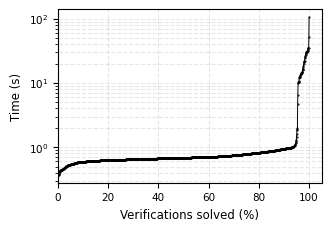

In [5]:
def extract_durations_seconds(data):
    verifications = data.get('c_edge_verifications', [])
    return [float(v['duration_ms']) / 1000.0 for v in verifications if 'duration_ms' in v]

durations_by_benchmark = {
    name: extract_durations_seconds(data)
    for name, data in datasets.items()
}
durations_by_benchmark['TPC-C no split'] = []

CACTUS_MARKER = 'o'
CACTUS_MARKER_SIZE = 0.5
CACTUS_LINEWIDTH = 0.7

# ── Figure: A4 text-width, compact height ──────────────────────────────
fig_w = 3.2                # ≈ ~1/3 A4 text width (inches)
fig_h = 2.2                # ~1/3 A4 text width (inches)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

LABEL_FS  = 8.5
TICK_FS   = 7.5
LEGEND_FS = 6.5

# ── Per-benchmark lines (normalized x-axis → percentage) ──────────────
active = sorted(n for n in durations_by_benchmark
                if len(durations_by_benchmark[n]) > 0)

combined = sorted(t for ts in durations_by_benchmark.values() for t in ts)
if combined:
    combined = np.asarray(combined, dtype=float)
    pct = np.arange(1, len(combined) + 1) / len(combined) * 100.0
    ax.plot(pct, combined,
            linewidth=CACTUS_LINEWIDTH,
            marker=CACTUS_MARKER, markersize=CACTUS_MARKER_SIZE,
            color='black')

# ── Axes, grid, no title ──────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(0, 105)
ax.set_xlabel('Verifications solved (%)', fontsize=LABEL_FS)
ax.set_ylabel('Time (s)',                 fontsize=LABEL_FS)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# ── Compact legend (multi-column, upper-left where plot is empty) ─────
# ax.legend(
#     fontsize=LEGEND_FS,
#     ncol=3,
#     loc='upper left',
#     framealpha=0.85,
#     borderpad=0.4,
#     handlelength=1.5,
#     handletextpad=0.4,
#     columnspacing=1.0,
# )

fig.tight_layout(pad=0.3)
fig.savefig(OUTPUT_ROOT / 'cactus_plot.pdf', bbox_inches='tight')
plt.show()

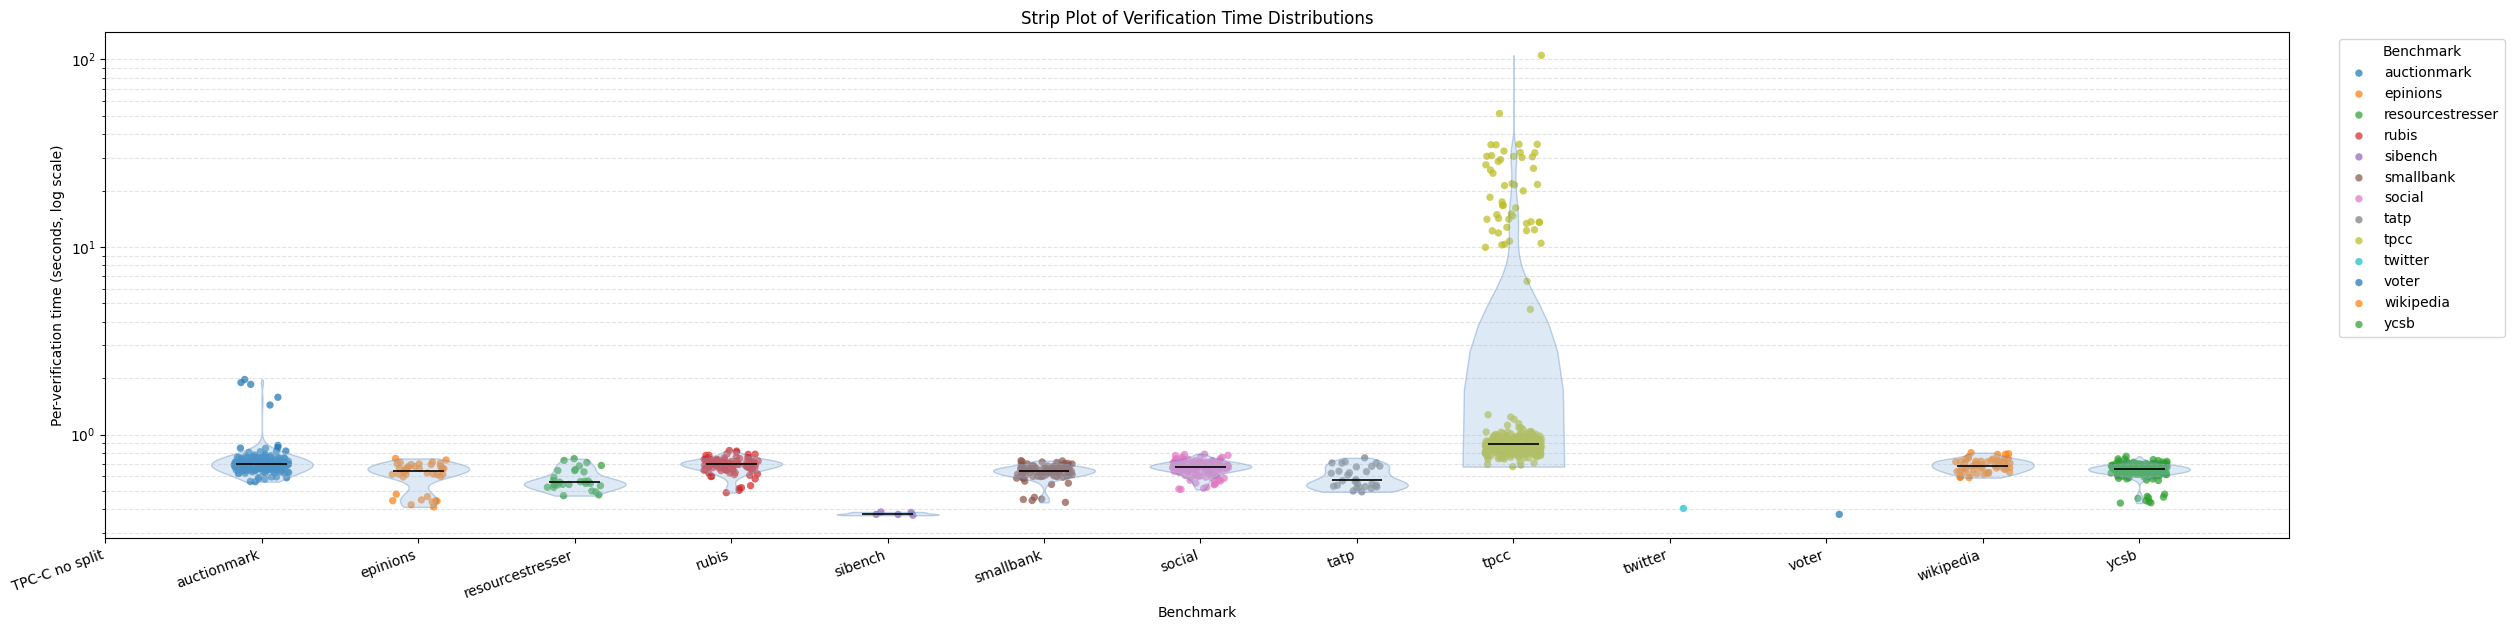

In [6]:
# Strip plot (manual jittered scatter), robust even when a benchmark has only one point
benchmarks = sorted(durations_by_benchmark.keys())
rng = np.random.default_rng(42)

# Overlay options: 'none', 'box', 'violin'
OVERLAY_MODE = 'violin'
SHOW_POINTS = True

fig, ax = plt.subplots(figsize=(max(10, 1.8 * len(benchmarks)), 6.4))

overlay_positions = []
overlay_values = []

for i, bench in enumerate(benchmarks, start=1):
    times = np.array(durations_by_benchmark[bench], dtype=float)
    if len(times) == 0:
        continue

    if SHOW_POINTS:
        x_jitter = i + rng.uniform(-0.18, 0.18, size=len(times))
        ax.scatter(x_jitter, times, s=28, alpha=0.72, edgecolors='none', label=bench)

    # Keep only groups with >1 point for distribution overlays
    if len(times) > 1:
        overlay_positions.append(i)
        overlay_values.append(times)

if OVERLAY_MODE == 'box' and overlay_values:
    bp = ax.boxplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
    )
    for patch in bp['boxes']:
        patch.set_facecolor('#9fc5e8')
        patch.set_alpha(0.35)

elif OVERLAY_MODE == 'violin' and overlay_values:
    vp = ax.violinplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.65,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_facecolor('#9fc5e8')
        body.set_edgecolor('#4f81bd')
        body.set_alpha(0.35)
    if 'cmedians' in vp:
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.2)

ax.set_xticks(np.arange(1, len(benchmarks) + 1))
ax.set_xticklabels(benchmarks, rotation=20, ha='right')
ax.set_yscale('log')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Per-verification time (seconds, log scale)')
ax.set_title('Strip Plot of Verification Time Distributions')
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.35)

# Avoid duplicate legend entries for points
if SHOW_POINTS:
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), title='Benchmark', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'strip_plot.pdf')
plt.show()

In [7]:
summary_rows = []

# Keep report names aligned with what is actually loaded in datasets.
report_benchmarks = sorted(datasets.keys())

for benchmark_name in report_benchmarks:
    data = datasets.get(benchmark_name)
    verifications = data.get('c_edge_verifications', []) if data is not None else []
    summary = data.get('summary', {}) if data is not None else {}
    
    sc_cycle_removed = summary.get('verification_pre_sc_cycle_count', 0) - summary.get('verification_post_sc_cycle_count', 0)
    merges_removed = summary.get('verification_pre_merged_node_count', 0) - summary.get('verification_post_merged_node_count', 0)
    merge_node_size_pre = summary.get('verification_pre_average_merged_node_size', 0)
    merge_node_size_post = summary.get('verification_post_average_merged_node_size', 0)
    merge_node_size_reduction = (merge_node_size_pre - merge_node_size_post) if merge_node_size_pre > 0 else 0.0

    total_count = len(verifications)
    pass_count = sum(1 for v in verifications if v.get('result') == 'Pass')
    error_count = sum(1 for v in verifications if v.get('result') == 'Error')
    timeout_count = sum(1 for v in verifications if v.get('result') == 'Timeout')
    
    commutative_rate = (pass_count / total_count * 100.0) if total_count > 0 else 0.0

    if total_count > 0:
        durations = np.array([float(v['duration_ms']) / 1000.0 for v in verifications], dtype=float)
        total_time = float(np.sum(durations))
        median_time = float(np.median(durations))
        p95_time = float(np.percentile(durations, 95))
        max_time = float(np.max(durations))
    else:
        total_time = 0.0
        median_time = 0.0
        p95_time = 0.0
        max_time = 0.0

    summary_rows.append({
        'Benchmark': benchmark_name,
        'Total C-Edges': total_count,
        'Commutative (Pass)': pass_count,
        'Non-Commutative': error_count,
        'Timeouts': timeout_count,
        'Commutative Rate (%)': f'{commutative_rate:.1f}',
        'Total Time (s)': f'{total_time:.2f}',
        'Median Time (s)': f'{median_time:.4f}',
        'P95 Time (s)': f'{p95_time:.4f}',
        'Max Time (s)': f'{max_time:.4f}',
        'SC Cycles Removed': sc_cycle_removed,
        'Merges Removed': merges_removed,
        'Merge Node Size Pre': f'{merge_node_size_pre:.2f}',
        'Merge Node Size Post': f'{merge_node_size_post:.2f}',
        'Merge Node Size Reduction': f'{merge_node_size_reduction:.2f}',
    })

summary_df = pd.DataFrame(summary_rows)[[
    'Benchmark',
    'Total C-Edges',
    'Commutative (Pass)',
    'Non-Commutative',
    'Timeouts',
    'Commutative Rate (%)',
    'Total Time (s)',
    'Median Time (s)',
    'P95 Time (s)',
    'Max Time (s)',
    'SC Cycles Removed',
    'Merges Removed',
    'Merge Node Size Pre',
    'Merge Node Size Post',
    'Merge Node Size Reduction',
]]

print('\n' + '=' * 160)
print('BENCHMARK SUMMARY')
print('=' * 160)
print(summary_df.to_string(index=False))
print('=' * 160)

print('\nDetailed breakdown:\n')
for row in summary_rows:
    print(f"{row['Benchmark']}:")
    print(f"  Total C-edges:           {row['Total C-Edges']}")
    print(f"  Commutative (Pass):      {row['Commutative (Pass)']}")
    print(f"  Non-Commutative:         {row['Non-Commutative']}")
    print(f"  Timeouts:                {row['Timeouts']}")
    print(f"  Commutative Rate:        {row['Commutative Rate (%)']}%")
    print(f"  Total Time:              {row['Total Time (s)']} seconds")
    print(f"  Median Time:             {row['Median Time (s)']} seconds")
    print(f"  P95 Time:                {row['P95 Time (s)']} seconds")
    print(f"  Max Time:                {row['Max Time (s)']} seconds\n")
    print(f"  SC Cycles Removed:       {row['SC Cycles Removed']}")
    print(f"  Merges Removed:          {row['Merges Removed']}")
    print(f"  Merge Node Size Pre:     {row['Merge Node Size Pre']}")
    print(f"  Merge Node Size Post:    {row['Merge Node Size Post']}")
    print(f"  Merge Node Size Reduction: {row['Merge Node Size Reduction']}")


BENCHMARK SUMMARY
       Benchmark  Total C-Edges  Commutative (Pass)  Non-Commutative  Timeouts Commutative Rate (%) Total Time (s) Median Time (s) P95 Time (s) Max Time (s)  SC Cycles Removed  Merges Removed Merge Node Size Pre Merge Node Size Post Merge Node Size Reduction
  TPC-C no split            284                 232               51         0                 81.7      147281.35          0.8894     567.0075   25364.3632                  0               0                0.00                 0.00                      0.00
     auctionmark            156                  34              122         0                 21.8         113.72          0.6932       0.8457       1.9666                  0               0                2.00                 2.00                      0.00
        epinions             40                   0               40         0                  0.0          24.42          0.6421       0.7139       0.7455                  0               0             